In [50]:
# %matplotlib notebook
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm, ticker

In [51]:
with open('./grid_output.dat', 'r') as f:
    params = f.read().split('\n')[1].split()
N_elements = int(params[0])
N_molecules = int(params[1])
N_condensates = int(params[2])

In [52]:
df = pd.read_csv('./grid_output.dat', skiprows=2,
                 delim_whitespace=True)
df.rename(columns = {'Tg':'T_K', 'pgas':'p_ubar'}, inplace=True)
n_p=100
n_T=100
T_K = np.array(df['T_K']).reshape((n_p,n_T))
p_bar = np.array(df['p_ubar']).reshape((n_p,n_T)) / 1e6
# df.set_index(
#     ['T_K', 'p_ubar'], inplace=True
# )
df.tail()

,T_K,nHges,p_ubar,el,H,C,N,O,F,S,...,epsMg,epsCa,epsAl,epsNa,epsK,epsTi,dust/gas,dustVol/H,Jstar(W),Nstar(W)
9995,1911.208689,2.776734e+18,1.000000e+10,-300.0,12.825907,-1.844457,10.210858,16.177780,12.334643,10.062669,...,-5.837269,-7.986614,-2.114725,-1.184344,-1.831681,-7.317021,3.319125,-15.108543,-300.0,999999.99999
9996,1933.029947,2.720617e+18,1.000000e+10,-300.0,12.908889,-1.581851,10.351811,16.287726,12.407039,10.236163,...,-5.775100,-7.908482,-2.110228,-1.072292,-1.739443,-7.121571,3.314201,-15.108545,-300.0,999999.99999
9997,1955.100350,2.661546e+18,1.000000e+10,-300.0,12.990539,-1.322444,10.490747,16.396116,12.478104,10.407682,...,-5.712595,-7.827621,-2.106004,-0.960449,-1.646803,-6.927693,3.308455,-15.108548,-300.0,999999.99999
9998,1977.422742,2.599146e+18,1.000000e+10,-300.0,13.070794,-1.066303,10.627631,16.502965,12.547798,10.577239,...,-5.649979,-7.744471,-2.102046,-0.848788,-1.553831,-6.752482,3.301764,-15.108517,-300.0,999999.99999
9999,2000.000000,2.533020e+18,1.000000e+10,-300.0,13.149578,-0.813509,10.762415,16.608283,12.616072,10.744847,...,-5.587464,-7.659485,-2.098349,-0.737248,-1.460553,-6.583023,3.293987,-15.108521,-300.0,999999.99999


In [53]:
gas_species_names = np.array(df.columns[3:4+N_elements+N_molecules])
df_mol = df[gas_species_names]
gas_species_cm3 = np.array(df_mol).reshape(
    (n_p, n_T, 1+N_elements+N_molecules)
)
gas_species_cm3 = np.rollaxis(gas_species_cm3, 2) # put species axis first
# Demonstrating that T_K, p_bar and gas_species_cm3 all have the right shape
print(f'T = {T_K[-1,-4]}K \t p = {p_bar[-1,-4]}bar \t[H] = {gas_species_cm3[1,-1,-4]}cm^-3')
print(df.iloc[-4][['T_K','p_ubar','H']])
# Converting to a mixing ratio
gas_species_mr = 10**gas_species_cm3 / np.sum(10**gas_species_cm3, axis=0)

T = 1933.029947K 	 p = 10000.0bar 	[H] = 12.9088889256cm^-3
T_K       1.933030e+03
p_ubar    1.000000e+10
H         1.290889e+01
Name: 9996, dtype: float64


In [54]:
condensate_colnames = np.array(
    df.columns[4+N_elements+N_molecules+N_condensates:
               4+N_elements+N_molecules+2*N_condensates]
)
df_cond = df[condensate_colnames]
condensates_orig_units = np.array(df_cond).reshape(
    (n_p,n_T, N_condensates)
)
condensates_orig_units = np.rollaxis(condensates_orig_units, 2) # species axis first
# Converting to a mole fraction
condensates_mf = 10**condensates_orig_units / np.sum(10**condensates_orig_units, axis=0)

In [55]:
important_molecules = [
    'CO2','N2',
#     'SO2','COS','H2S','S2',
    'CO','H2O',
#     'H2','HCL','HF',#'Ar','Ne',
#     'H2SO4'
]
selected_condensates = [
#     'Al2SiO5','Al2O3','SiO2','MgAl2O4'
#     'CaMgC2O6',
#     'Mg3Si4O12H2',
#     'MgCO3','MgF2','MgSiO3',
#     'FeS2',
#     'Fe2O3','Fe3O4','FeO',
#     'NaCl',
#     'CaAl2Si2O8','NaAlSi3O8','KAlSi3O8','CaSO4',
#     'TiO2','Mn3Al2Si3O12'
    'CaSO4','CaMgSi2O6',
    'MgF2','FeS2',
]

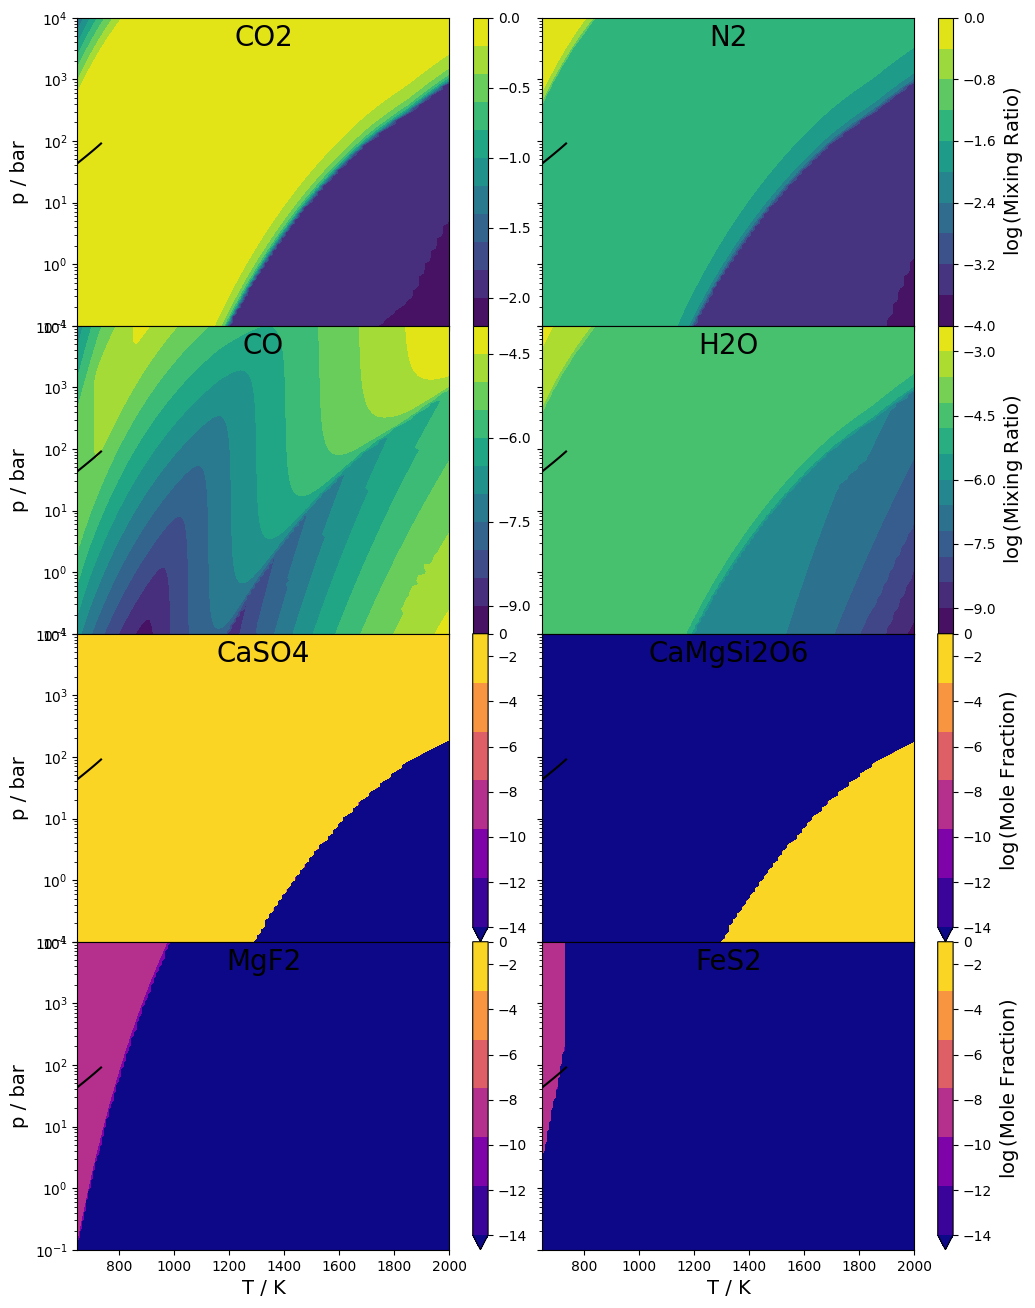

In [56]:
T_K = np.array(df['T_K']).reshape((100,100))
p_bar = np.array(df['p_ubar']).reshape((100,100)) / 1e6

n_mol = len(important_molecules)
n_cond = len(selected_condensates)
n_axes = n_mol + n_cond
n_rows = int(np.ceil(n_axes / 2))
fg, axs = plt.subplots(n_rows, 2,
                       figsize=(12, n_rows*4),
                      sharex=True, sharey=True)

for i, ax in enumerate(axs.ravel()):
    if i==n_axes-1 or i==n_axes-2:
        ax.set_xlabel('T / K', fontsize=14)
    if i%2==0:
        ax.set_ylabel('p / bar', fontsize=14)
    ax.set_yscale('log')
    ax.set_title((important_molecules + selected_condensates)[i], fontsize=20,
                y=1., pad=-20.)
fg.subplots_adjust(hspace=0, wspace=0) # pushing axes together

# Gas species
concs_all = gas_species_mr[[nm in important_molecules for nm in gas_species_names],:,:]
vmn = -8#np.floor(np.log10(np.min(concs_all)))
vmx = np.ceil(np.log10(np.max(concs_all)))
nbins = int(vmx-vmn) //2 + 1
for i, molecule in enumerate(important_molecules):
    ax = axs.reshape((n_axes,))[i]
    concs = gas_species_mr[gas_species_names==molecule][0]
    contf = ax.contourf(T_K, p_bar,
                        np.log10(concs),
#                         levels=np.log10(np.logspace(vmn, vmx, nbins)),
                        levels=10,
                        cmap=mpl.cm.viridis,
#                         extend='min'
                       )
    cbar = fg.colorbar(contf, ax=ax)
    cbar.locator = ticker.MaxNLocator(nbins=nbins)
    cbar.update_ticks()
    if i%2 == 1:
        cbar.ax.set_ylabel('$\log$(Mixing Ratio)', fontsize=14)
# Condensates
concs_all = condensates_mf[[nm[1:] in selected_condensates for nm in condensate_colnames],:,:]
vmn = -14#np.floor(np.log10(np.min(concs_all)))
vmx = np.ceil(np.log10(np.max(concs_all)))
nbins = int(vmx-vmn) // 2 + 1
for j, condensate in enumerate(selected_condensates):
    ax = axs.reshape((n_axes,))[i+j+1]
    concs = condensates_mf[condensate_colnames==f'n{condensate}'][0]
    contf = ax.contourf(T_K, p_bar,
                        np.log10(concs),
                        levels=np.log10(np.logspace(vmn, vmx, nbins)),
                        cmap=mpl.cm.plasma,
                        extend='min'
                       )
    cbar = fg.colorbar(contf, ax=ax)
    cbar.locator = ticker.MaxNLocator(nbins=nbins)
    cbar.update_ticks()
    if j%2==1:
        cbar.ax.set_ylabel('$\log$(Mole Fraction)', fontsize=14);
        
venus_structure = pd.read_csv('../GGchem/structures/VenusHighResFit.dat',
                              delim_whitespace=True,
                             index_col=0)[1:].set_index('z[km]')
venus_structure = venus_structure[venus_structure.index < 12]
for ax in axs.ravel():
    ax.plot(venus_structure['T[K]'],
             venus_structure['P[bar]'], c='k')
    ax.set_xlim([650,2000])

Text(0.5, 1.0, 'Dominant Minerals at $p=1$bar')

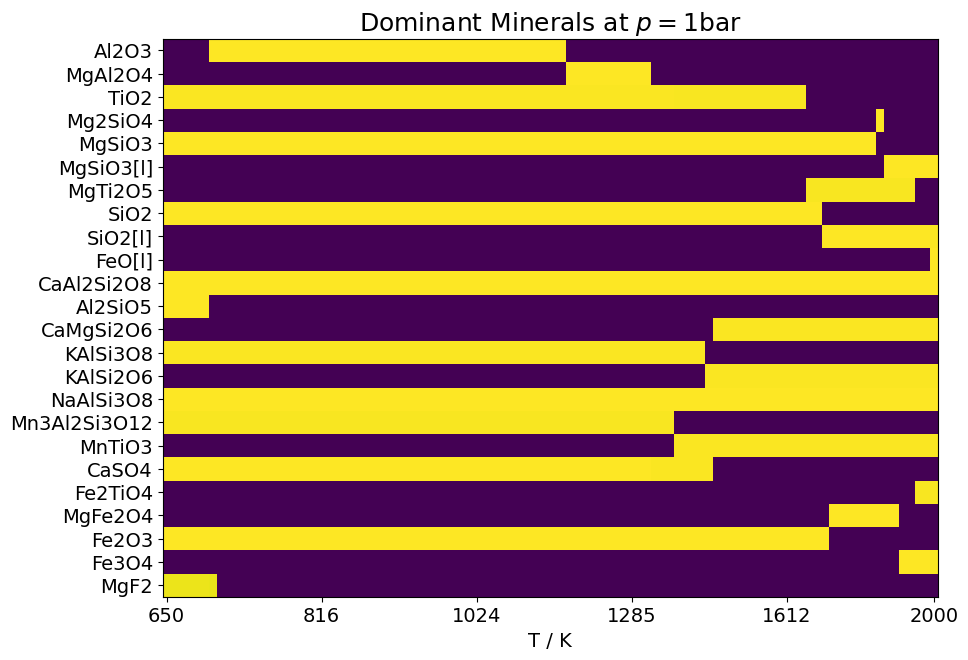

In [57]:
p_slice = 1
abunds = condensates_mf[:,np.abs(p_bar-p_slice)<=.05]
d_dTs = np.diff(abunds, axis=1)
interesting = np.max(np.abs(d_dTs), axis=1)>1e-50
fg, ax = plt.subplots(figsize=(10,10))
ims = ax.imshow(np.log10(abunds[interesting,:]),
                aspect=3, interpolation='none')
# fg.colorbar(ims, ax=ax)
ax.set_yticks(np.arange(len(condensate_colnames[interesting])))
ax.set_yticklabels(np.array([cn[1:] for cn in condensate_colnames[interesting]]), fontsize=14);
label_inds = [0,20,40,60,80,99]
ax.set_xticks(label_inds)
ax.set_xticklabels([f'{T_K[0,:][i]:.0f}' for i in label_inds], fontsize=14);
ax.set_xlabel('T / K', fontsize=14)
ax.set_title('Dominant Minerals at $p=1$bar', fontsize=18)

In [145]:
## Moving data into a smaller (npz) file
# Gas species
gas_species_abundance_cutoff=-300
is_above_cutoff = np.any(
    gas_species_cm3 > gas_species_abundance_cutoff,
    axis=(1,2)
) # Will be all except 'el'
gas_species_above_cutoff = gas_species_names[is_above_cutoff]
gas_species_present_mr = gas_species_mr[is_above_cutoff,:,:]

# Condensates
condensate_abundance_cutoff=-3
is_above_cutoff = np.any(
    condensates_orig_units > condensate_abundance_cutoff,
    axis=(1,2)
) # 29 mineral species
condensates_above_cutoff = np.array([
    cn[1:] for cn in condensate_colnames[is_above_cutoff]
])
condensates_present_mf = condensates_mf[is_above_cutoff,:,:]

In [154]:
np.savez_compressed(
    './grid_results.npz',
    gas_species_names = gas_species_above_cutoff,
    gas_species_mr = gas_species_present_mr,
    condensates_names = condensates_above_cutoff,
    condensates_mf = condensates_present_mf
)